<a href="https://colab.research.google.com/github/coder-Basundhara/Inhouse-training-projects/blob/main/InhouseIntershipselfproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Ecommerce Customers.csv to Ecommerce Customers.csv


In [4]:
df = pd.read_csv("Ecommerce Customers.csv")
df.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [5]:
df = df.drop(columns=["Email", "Address"])
df.head()


,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [6]:
X = df.drop("Yearly Amount Spent", axis=1)
y = df["Yearly Amount Spent"]


In [7]:
categorical_features = ["Avatar"]
numerical_features = [
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


In [11]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("decision_tree", dt)
])


In [12]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Avatar']),
                                                 ('num', 'passthrough',
                                                  ['Avg. Session Length',
                                                   'Time on App',
                                                   'Time on Website',
                                                   'Length of Membership'])])),
                ('decision_tree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

In [13]:
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


MAE : 26.10849998003175
MSE : 1131.6524763229706
RMSE: 33.640042751503316
R2  : 0.7714632505699441


In [25]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape)


MAPE: 0.05343552790207773


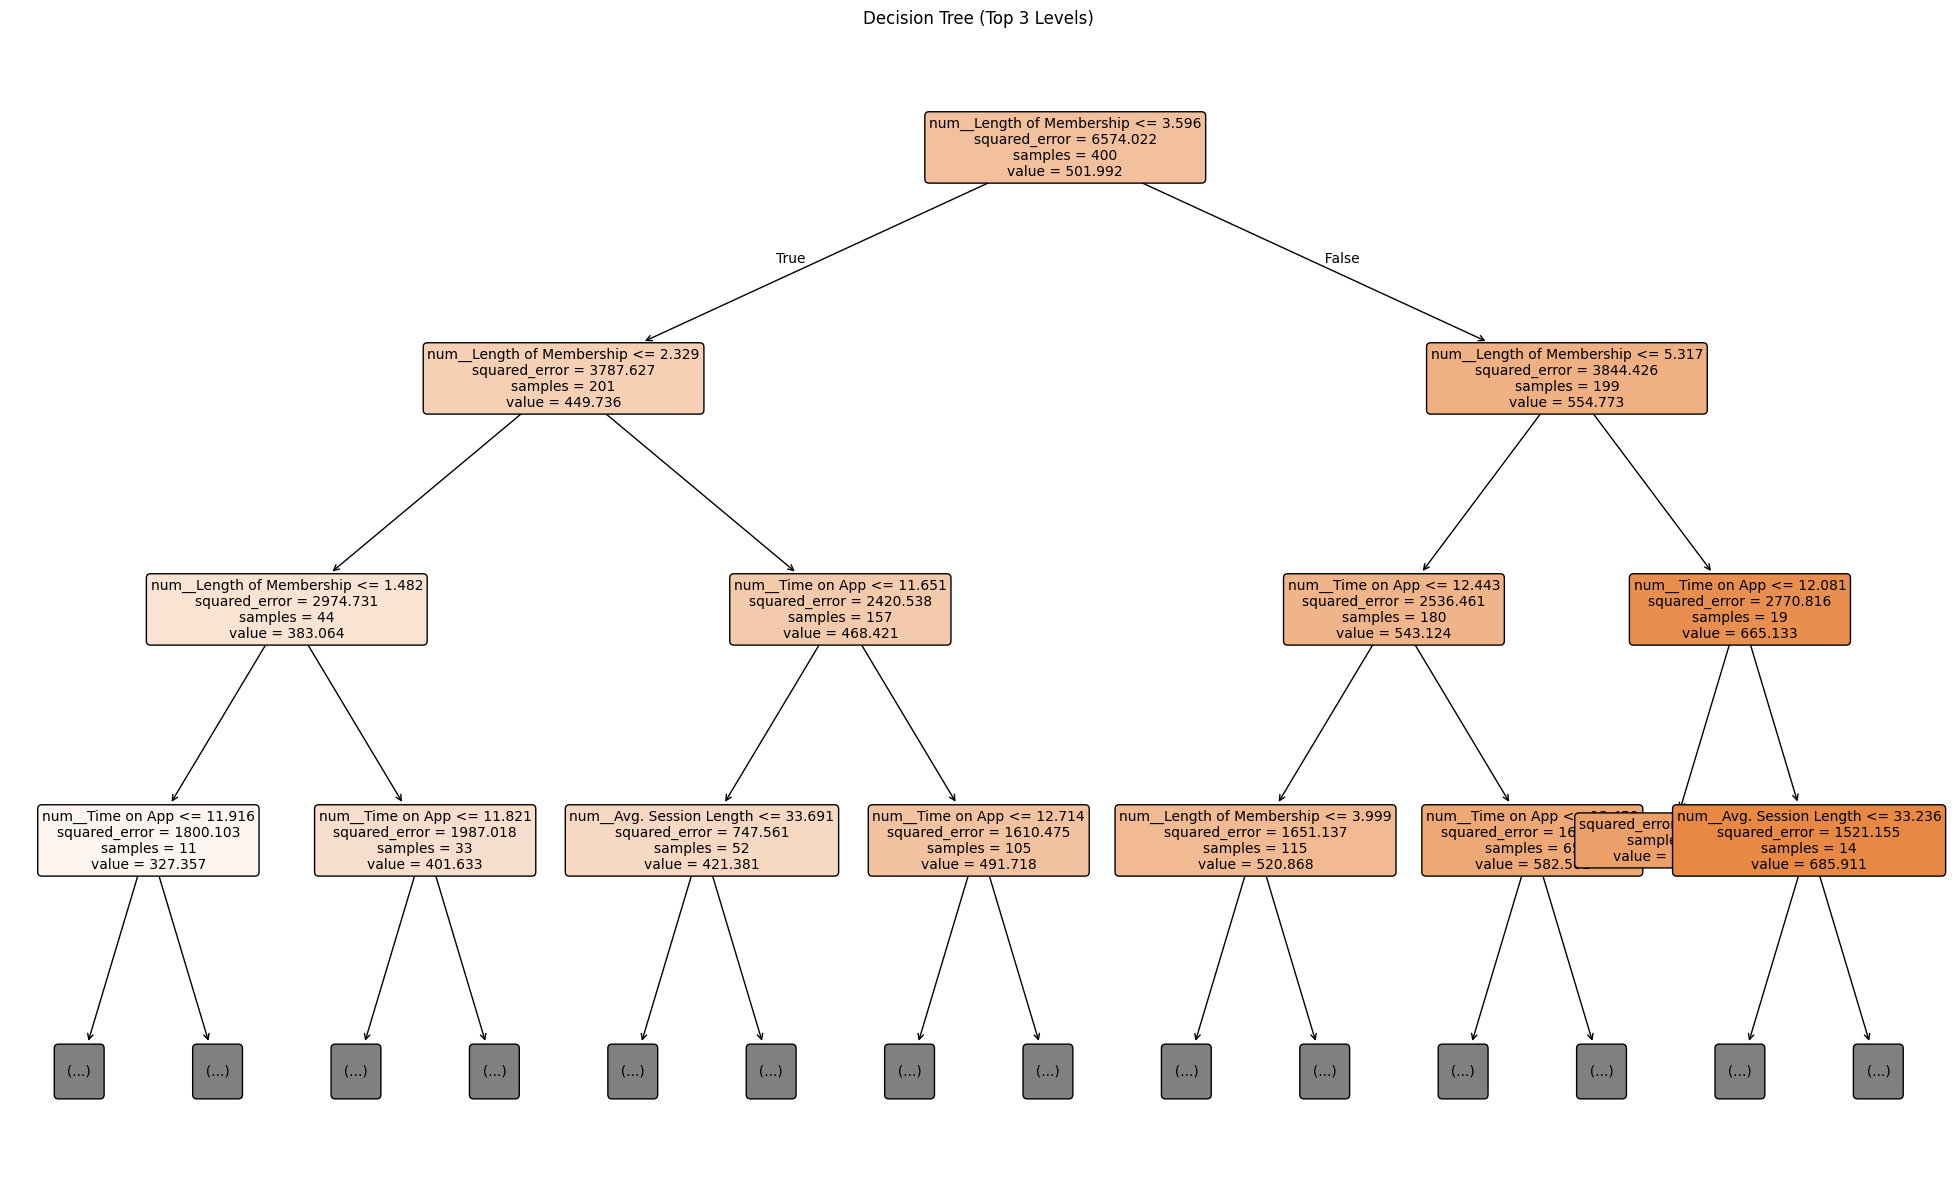

In [34]:
plt.figure(figsize=(25, 15))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Decision Tree (Top 3 Levels)")
plt.show()


In [21]:
new_customer = pd.DataFrame({
    "Avatar": ["Violet"],
    "Avg. Session Length": [34.49726773],
    "Time on App": [12.65565115],
    "Time on Website": [39.57766802],
    "Length of Membership": [4.082620633]
})

prediction = model.predict(new_customer)
print("Predicted Yearly Amount Spent:", prediction[0])


Predicted Yearly Amount Spent: 580.958002552381


In [22]:
# Extract trained decision tree
tree = model.named_steps["decision_tree"]

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get importance values
importances = tree.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df


,Feature,Importance
136,num__Length of Membership,0.737911
134,num__Time on App,0.212362
133,num__Avg. Session Length,0.041118
135,num__Time on Website,0.008609
4,cat__Avatar_Azure,0.000000
...,...,...
125,cat__Avatar_Tomato,0.000000
132,cat__Avatar_YellowGreen,0.000000
131,cat__Avatar_Yellow,0.000000
130,cat__Avatar_WhiteSmoke,0.000000


In [24]:
unknown_customer_1 = pd.DataFrame({
    "Avatar": ["Green"],
    "Avg. Session Length": [32.1],
    "Time on App": [10.2],
    "Time on Website": [37.8],
    "Length of Membership": [2.3]
})

prediction_1 = model.predict(unknown_customer_1)
print("Prediction for unknown customer 1:", prediction_1[0])


Prediction for unknown customer 1: 393.4752139111111


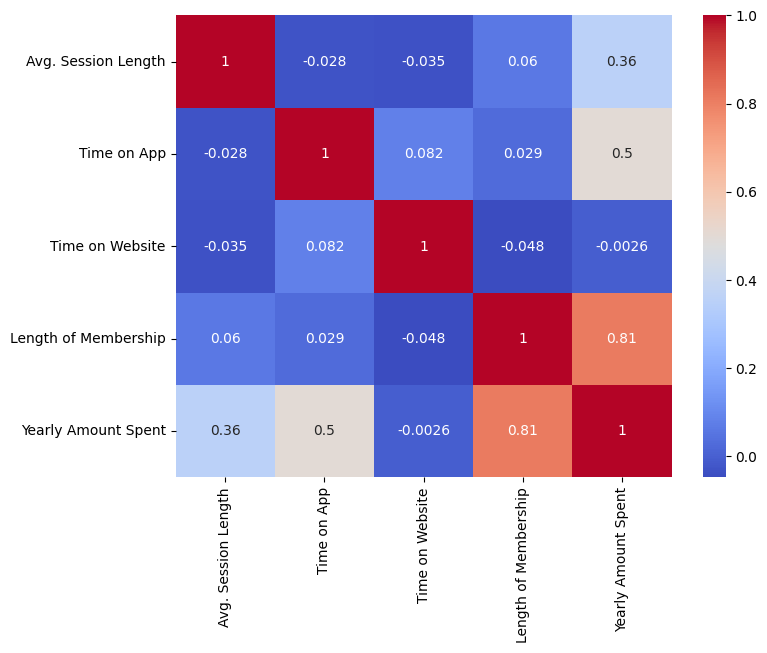

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


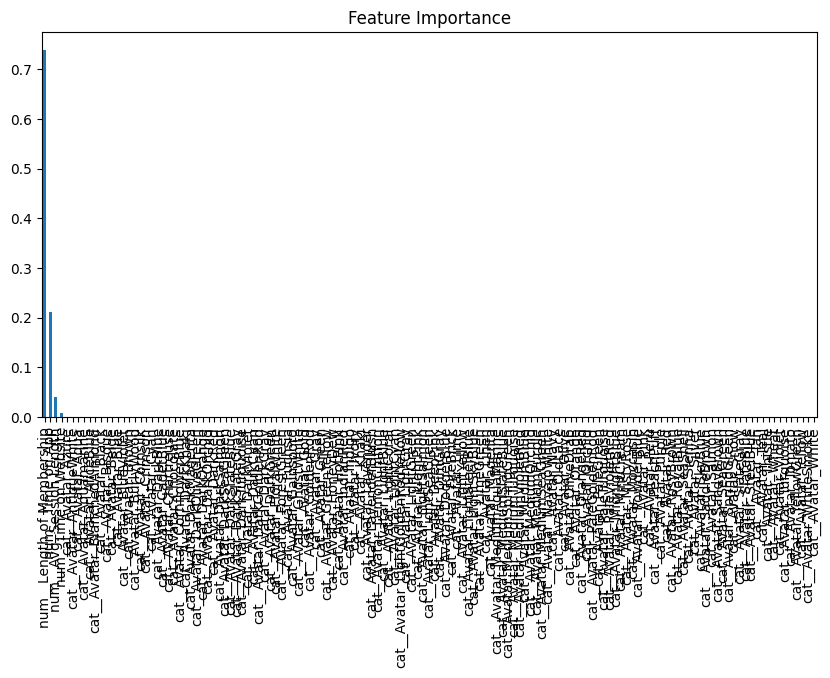

In [31]:
import pandas as pd

importance = pd.Series(
    dt.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()
